In [1]:
import numpy as np 
import pandas as pd

data = pd.read_csv("Food_Delivery_Time_Prediction.csv")

print(data.head(5))

  Order_ID       Customer_Location     Restaurant_Location  Distance  \
0  ORD0001  (17.030479, 79.743077)  (12.358515, 85.100083)      1.57   
1  ORD0002  (15.398319, 86.639122)  (14.174874, 77.025606)     21.32   
2  ORD0003  (15.687342, 83.888808)  (19.594748, 82.048482)      6.95   
3  ORD0004  (20.415599, 78.046984)  (16.915906, 78.278698)     13.79   
4  ORD0005  (14.786904, 78.706532)  (15.206038, 86.203182)      6.72   

  Weather_Conditions Traffic_Conditions  Delivery_Person_Experience  \
0              Rainy             Medium                           4   
1             Cloudy             Medium                           8   
2              Snowy             Medium                           9   
3             Cloudy                Low                           2   
4              Rainy               High                           6   

  Order_Priority Order_Time Vehicle_Type  Restaurant_Rating  Customer_Rating  \
0         Medium  Afternoon          Car                4.1 

In [2]:
print(data.shape[0])
print(data.shape[1])

200
15


In [3]:
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 15 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Order_ID                    200 non-null    object 
 1   Customer_Location           200 non-null    object 
 2   Restaurant_Location         200 non-null    object 
 3   Distance                    200 non-null    float64
 4   Weather_Conditions          200 non-null    object 
 5   Traffic_Conditions          200 non-null    object 
 6   Delivery_Person_Experience  200 non-null    int64  
 7   Order_Priority              200 non-null    object 
 8   Order_Time                  200 non-null    object 
 9   Vehicle_Type                200 non-null    object 
 10  Restaurant_Rating           200 non-null    float64
 11  Customer_Rating             200 non-null    float64
 12  Delivery_Time               200 non-null    float64
 13  Order_Cost                  200 non

In [4]:
print(data.isnull().sum())

Order_ID                      0
Customer_Location             0
Restaurant_Location           0
Distance                      0
Weather_Conditions            0
Traffic_Conditions            0
Delivery_Person_Experience    0
Order_Priority                0
Order_Time                    0
Vehicle_Type                  0
Restaurant_Rating             0
Customer_Rating               0
Delivery_Time                 0
Order_Cost                    0
Tip_Amount                    0
dtype: int64


In [5]:
data.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
195    False
196    False
197    False
198    False
199    False
Length: 200, dtype: bool

In [6]:
#One-Hot-Encoding

categorical_Variables = ['Weather_Conditions', 'Traffic_Conditions', 'Order_Priority', 'Order_Time', 'Vehicle_Type']

data = pd.get_dummies(data, columns = categorical_Variables, drop_first = True)


In [7]:
#Standardizing

X = data.drop('Delivery_Time', axis = 1)
y = data['Delivery_Time']

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
numeric_columns = ['Distance',    'Delivery_Person_Experience',    'Restaurant_Rating',    'Customer_Rating',    'Order_Cost',    'Tip_Amount']
X[numeric_columns] = scaler.fit_transform(X[numeric_columns])

In [8]:
#Descriptive statistics

# For numerical columns
numerical_cols = [ 'Distance','Delivery_Person_Experience','Restaurant_Rating','Customer_Rating', 'Order_Cost',  'Tip_Amount','Delivery_Time']
data[numerical_cols].describe()


,Distance,Delivery_Person_Experience,Restaurant_Rating,Customer_Rating,Order_Cost,Tip_Amount,Delivery_Time
count,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000
mean,11.498050,5.250000,3.738500,3.686500,1046.488700,46.616650,70.494950
std,6.841755,2.745027,0.703021,0.697063,548.568922,29.361706,29.830694
min,0.520000,1.000000,2.500000,2.600000,122.300000,1.240000,15.230000
25%,6.090000,3.000000,3.200000,3.100000,553.270000,21.602500,46.997500
50%,10.265000,5.000000,3.800000,3.700000,1035.950000,47.530000,72.775000
75%,16.497500,8.000000,4.300000,4.300000,1543.125000,70.245000,96.650000
max,24.900000,10.000000,5.000000,5.000000,1997.420000,99.740000,119.670000


In [9]:
print(data[numerical_cols].mode())
print('the variance is : \n',data[numerical_cols].var())

   Distance  Delivery_Person_Experience  Restaurant_Rating  Customer_Rating  \
0      1.32                         8.0                3.8              2.6   
1      3.25                         NaN                NaN              3.4   
2      4.33                         NaN                NaN              NaN   
3      6.09                         NaN                NaN              NaN   
4      7.38                         NaN                NaN              NaN   
5      7.87                         NaN                NaN              NaN   
6      9.17                         NaN                NaN              NaN   
7     10.00                         NaN                NaN              NaN   
8     10.11                         NaN                NaN              NaN   

   Order_Cost  Tip_Amount  Delivery_Time  
0     1813.25        2.22          66.84  
1         NaN       24.16            NaN  
2         NaN         NaN            NaN  
3         NaN         NaN            

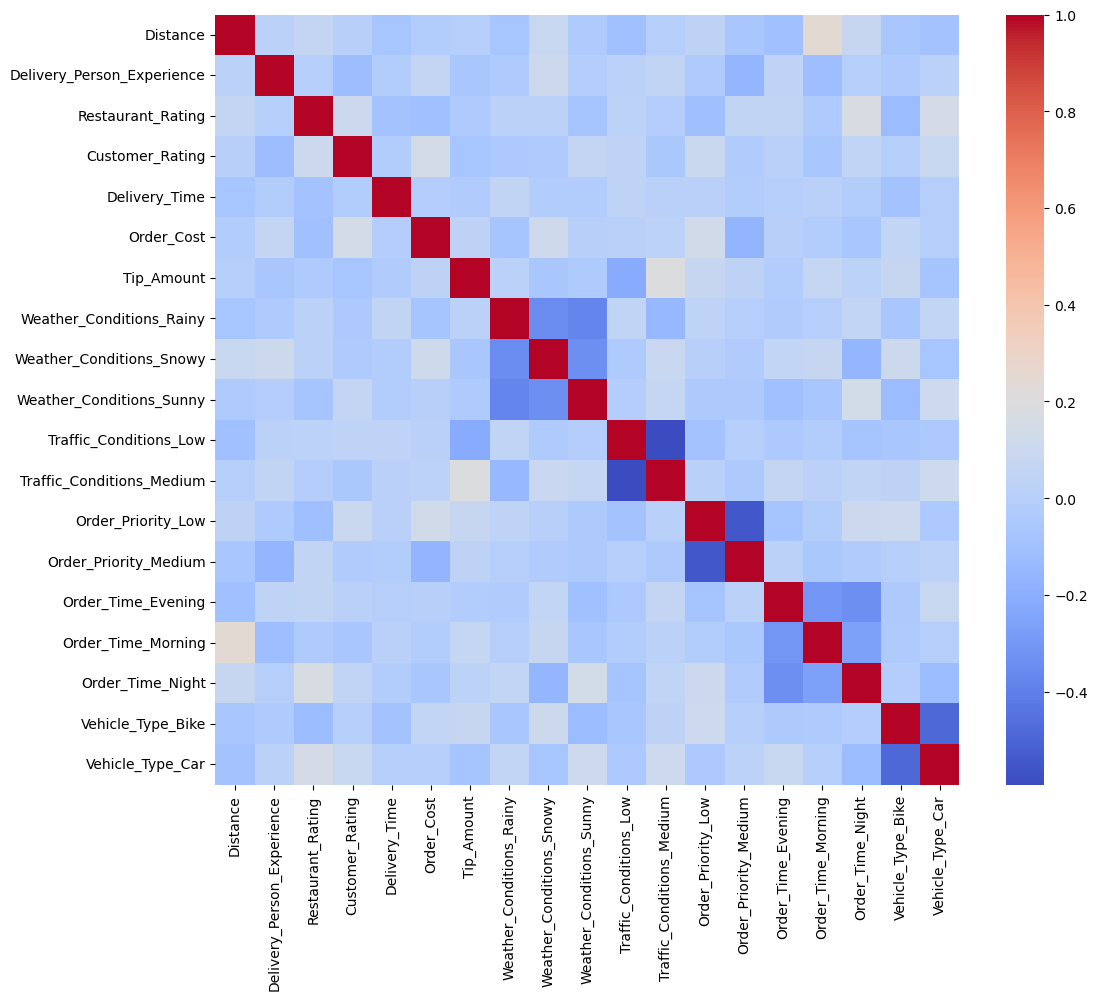

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt



correlation_matrix =data.select_dtypes(include=['number','bool']).corr()
plt.figure(figsize = (12,10))
sns.heatmap(correlation_matrix, cmap = 'coolwarm')
plt.show()

In [11]:
numeric_data = data.select_dtypes(include=['number','bool'])
corr_with_target = numeric_data.corr()['Delivery_Time'].sort_values(ascending=False)
print(corr_with_target)

Delivery_Time                 1.000000
Weather_Conditions_Rainy      0.054402
Traffic_Conditions_Low        0.039714
Order_Priority_Low            0.012849
Order_Time_Morning            0.011984
Traffic_Conditions_Medium     0.011810
Vehicle_Type_Car             -0.001372
Order_Time_Evening           -0.004021
Order_Cost                   -0.009307
Order_Time_Night             -0.013972
Order_Priority_Medium        -0.017798
Delivery_Person_Experience   -0.019098
Weather_Conditions_Sunny     -0.020492
Customer_Rating              -0.021952
Weather_Conditions_Snowy     -0.024621
Tip_Amount                   -0.029154
Distance                     -0.075143
Restaurant_Rating            -0.091855
Vehicle_Type_Bike            -0.091859
Name: Delivery_Time, dtype: float64


In [12]:
print(corr_with_target.abs().sort_values(ascending=False))

Delivery_Time                 1.000000
Vehicle_Type_Bike             0.091859
Restaurant_Rating             0.091855
Distance                      0.075143
Weather_Conditions_Rainy      0.054402
Traffic_Conditions_Low        0.039714
Tip_Amount                    0.029154
Weather_Conditions_Snowy      0.024621
Customer_Rating               0.021952
Weather_Conditions_Sunny      0.020492
Delivery_Person_Experience    0.019098
Order_Priority_Medium         0.017798
Order_Time_Night              0.013972
Order_Priority_Low            0.012849
Order_Time_Morning            0.011984
Traffic_Conditions_Medium     0.011810
Order_Cost                    0.009307
Order_Time_Evening            0.004021
Vehicle_Type_Car              0.001372
Name: Delivery_Time, dtype: float64


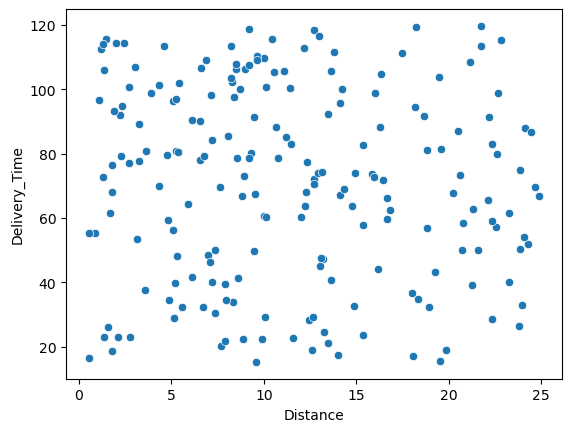

In [13]:
sns.scatterplot(x='Distance', y='Delivery_Time', data=data)
plt.show()

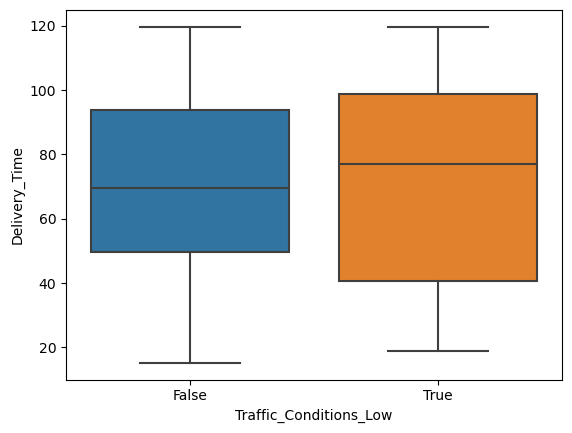

In [14]:
sns.boxplot(x='Traffic_Conditions_Low', y='Delivery_Time', data=data)
plt.show()

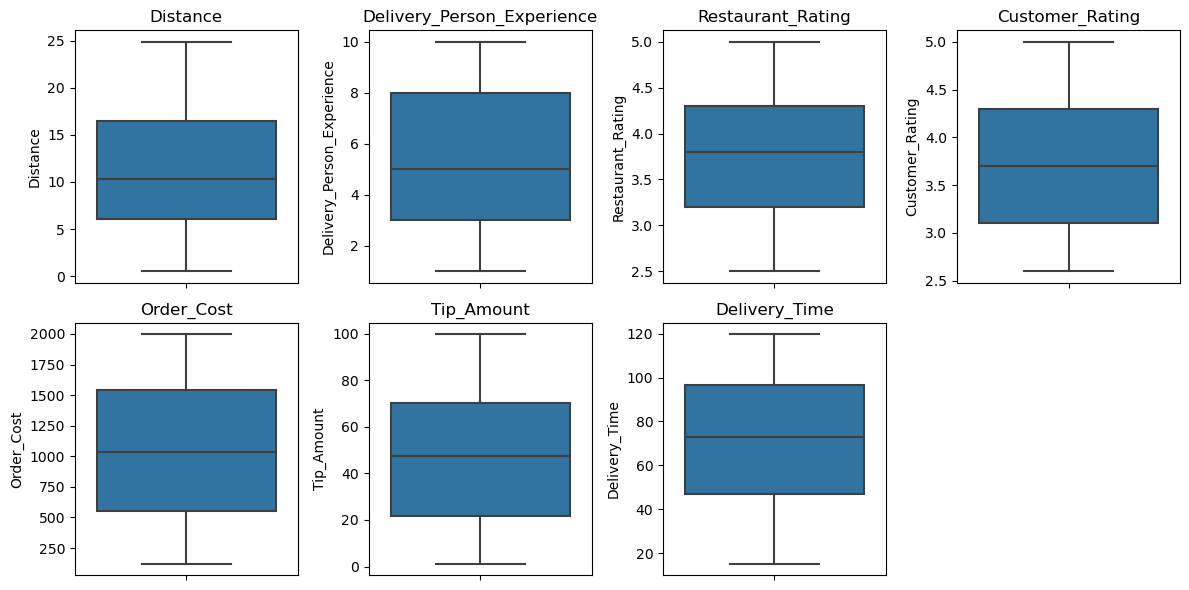

In [15]:
plt.figure(figsize=(12,6))

for i, col in enumerate(numerical_cols):
    plt.subplot(2,4,i+1)
    sns.boxplot(y=data[col])
    plt.title(col)

plt.tight_layout()
plt.show()

In [16]:
#handling outliers

Q1 = data['Delivery_Time'].quantile(0.25)
Q3 = data['Delivery_Time'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = data[(data['Delivery_Time'] >= lower) & 
        (data['Delivery_Time'] <= upper)]

In [17]:
#Feature Engineering
#using Haversine Formula

# Split coordinates into lat & lon

data[['cust_lat','cust_lon']] = data['Customer_Location'] \
    .str.strip('()').str.split(',', expand=True).astype(float)

data[['rest_lat','rest_lon']] = data['Restaurant_Location'] \
    .str.strip('()').str.split(',', expand=True).astype(float)

In [18]:
import numpy as np

def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # Earth radius in km
    
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    
    return R * c

data['Calculated_Distance'] = haversine(
    data['cust_lat'], data['cust_lon'],
    data['rest_lat'], data['rest_lon']
)

In [19]:
data[['Distance','Calculated_Distance']].head()

#calculated distance completely doesnot match the original distance.

,Distance,Calculated_Distance
0,1.57,775.651198
1,21.32,1042.385597
2,6.95,476.220706
3,13.79,389.912629
4,6.72,806.505886


In [20]:
#rush hour
data['Rush_Hour'] = (
    (data['Order_Time_Morning'] == 1) |
    (data['Order_Time_Evening'] == 1)
).astype(int)

In [21]:
#Linear Regression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

data.drop([
    'Order_ID',
    'Customer_Location',
    'Restaurant_Location',
    'cust_lat',
    'cust_lon',
    'rest_lat',
    'rest_lon',
    'Calculated_Distance'
], axis=1, inplace=True, errors='ignore')
X = data.drop('Delivery_Time', axis=1)
y = data['Delivery_Time']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [22]:
numeric_cols = [
    'Distance',
    'Delivery_Person_Experience',
    'Restaurant_Rating',
    'Customer_Rating',
    'Order_Cost',
    'Tip_Amount'
]

scaler = StandardScaler()

X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("MAE:", mae)
print("R²:", r2)

MSE: 1021.9359676315065
MAE: 27.184522740542167
R²: -0.10492559254944922


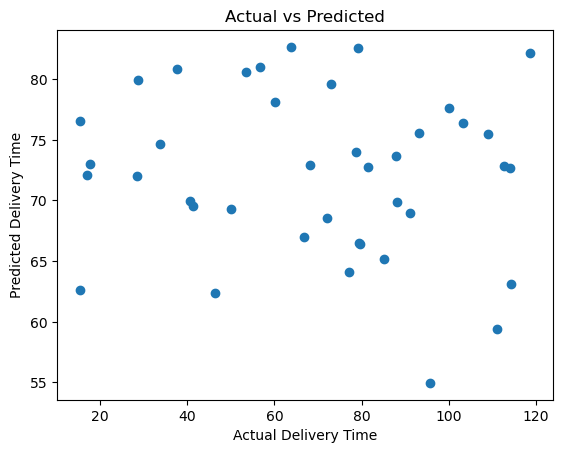

In [23]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)
plt.xlabel("Actual Delivery Time")
plt.ylabel("Predicted Delivery Time")
plt.title("Actual vs Predicted")
plt.show()

In [24]:
#Logistic Regression
median_time = data['Delivery_Time'].median()

data['Delivery_Status'] = data['Delivery_Time'].apply(
    lambda x: 1 if x > median_time else 0
)

In [25]:
X = data.drop(['Delivery_Time', 'Delivery_Status'], axis=1)
y = data['Delivery_Status']

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [26]:
numeric_cols = [
    'Distance',
    'Delivery_Person_Experience',
    'Restaurant_Rating',
    'Customer_Rating',
    'Order_Cost',
    'Tip_Amount'
]

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

In [27]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression()
log_model.fit(X_train, y_train)

from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression()
log_model.fit(X_train, y_train)
y_pred = log_model.predict(X_test)
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.4
Precision: 0.42857142857142855
Recall: 0.42857142857142855
F1 Score: 0.42857142857142855
Confusion Matrix:
 [[ 7 12]
 [12  9]]


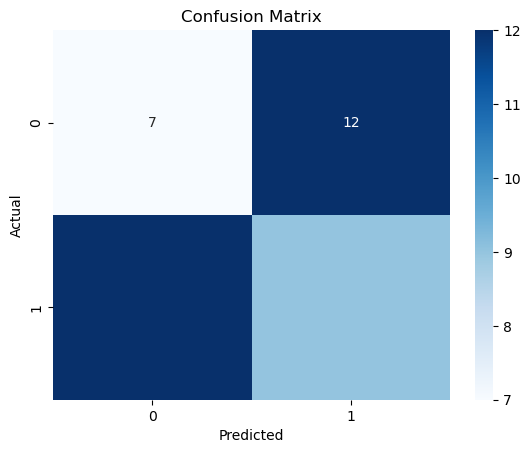

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

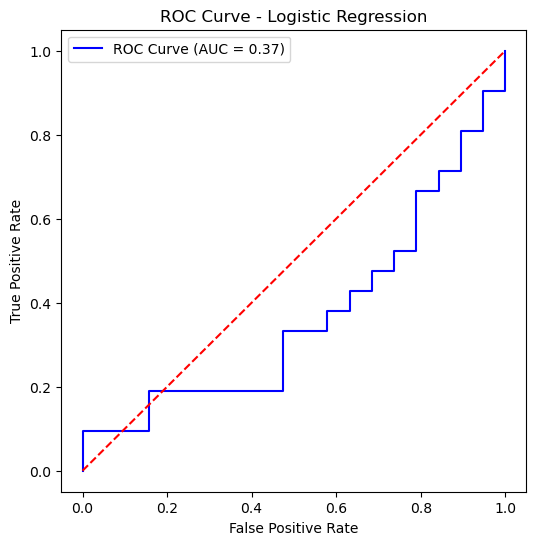

In [30]:
from sklearn.metrics import roc_curve, auc
y_prob = log_model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0,1], [0,1], color='red', linestyle='--')  # random baseline

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.show()